# Creating a basic model

## EDA

Import libraries

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import joblib
import tools as t

Downloading ETH-USD data

In [53]:
df = yf.download("ETH-USD", start="2022-01-01", end=t.CURRENT_DATE)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2022-01-01,3769.697021,3769.917969,3682.286621,3683.047119,9776191466
2022-01-02,3829.564941,3836.161865,3727.357422,3769.298340,9881471548
2022-01-03,3761.380371,3836.198730,3698.047607,3829.535645,12080777893
2022-01-04,3794.056641,3876.785156,3723.349854,3761.361572,14030925983
2022-01-05,3550.386963,3842.059814,3456.745361,3794.269043,18061338502


In [55]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1548 entries, 2022-01-01 to 2026-03-28
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ETH-USD)   1548 non-null   float64
 1   (High, ETH-USD)    1548 non-null   float64
 2   (Low, ETH-USD)     1548 non-null   float64
 3   (Open, ETH-USD)    1548 non-null   float64
 4   (Volume, ETH-USD)  1548 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 72.6 KB


Saving .csv to /data

In [54]:
df.to_csv(f"{t.DATA_PATH}/eth-2022-01-01-{t.CURRENT_DATE}.csv")

Extracting "Close"

In [56]:
close_prices = df["Close"]

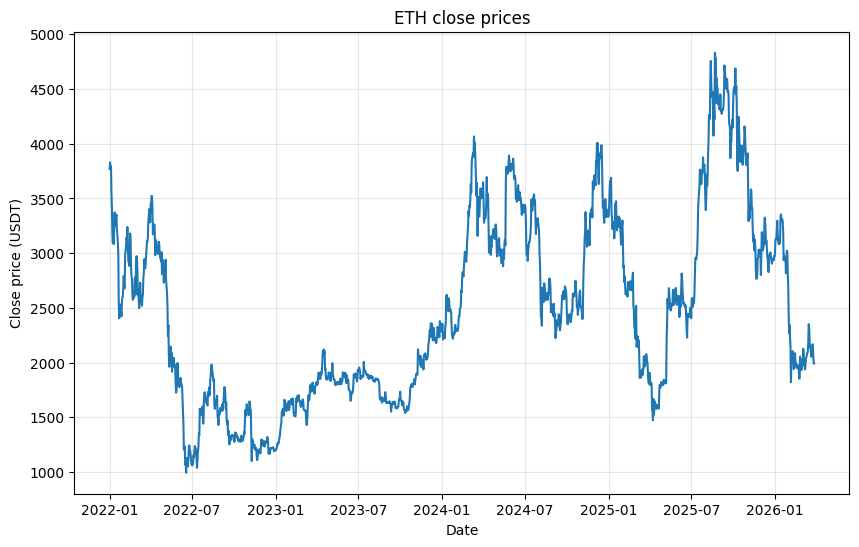

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(close_prices)
plt.grid(alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Close price (USDT)")
plt.title("ETH close prices")
plt.savefig(f"{t.IMAGE_PATH}/close_prices.png", format="png")
plt.show()

## Data preprocesing

Creating windows using function from tools.py

In [58]:
X, y = t.create_windows(close_prices)

In [59]:
print(X.shape)
print(y.shape)

(1532, 15, 1)
(1532,)


First 4 windows (sequences)

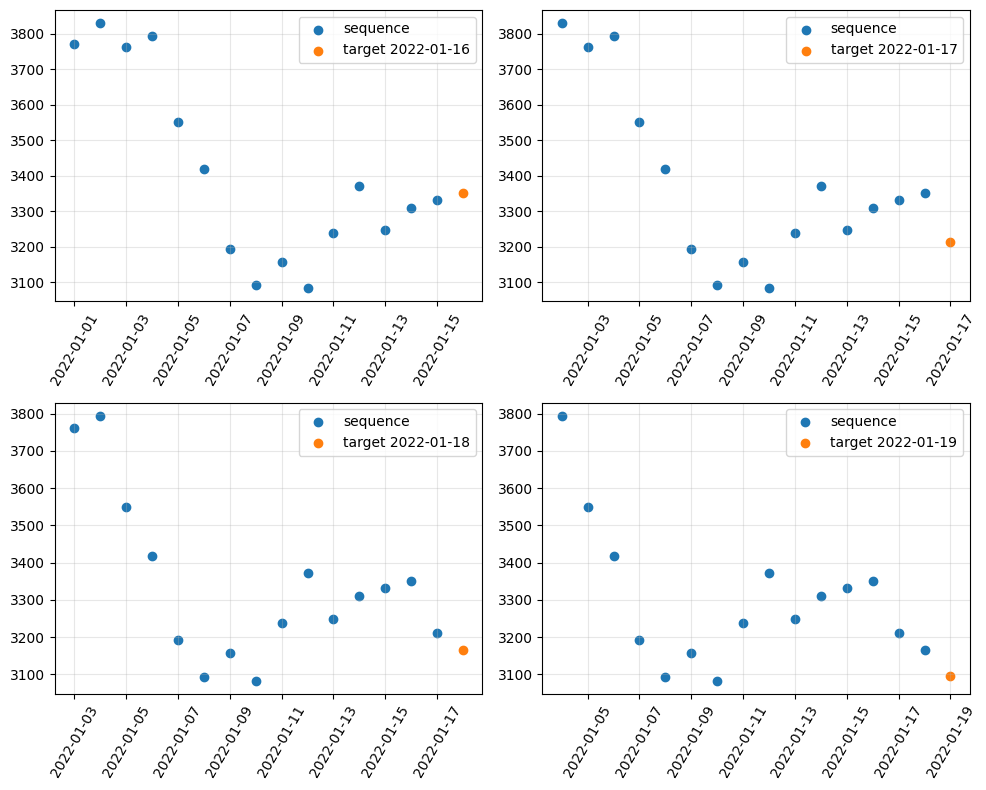

In [60]:
plt.figure(figsize=(10, 8))

for i, x in enumerate(X[:4]):
    target_date = df.index[i + t.TIME_STEP].date()
    plt.subplot(2, 2, i + 1)
    plt.scatter(df.index[i:i+t.TIME_STEP], x, label="sequence")
    plt.scatter(df.index[i + t.TIME_STEP], y[i], label=f"target {target_date}")
    plt.xticks(rotation=60)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.savefig(f"{t.IMAGE_PATH}/seq_examples.png", format="png")
plt.show()

Splitting and scaling data

In [61]:
X_train, X_val, X_test, y_train, y_val, y_test = t.split_and_scale_data(X, y, t.TRAIN_SPLIT, t.VAL_SPLIT)

In [62]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1225, 15, 1)
(230, 15, 1)
(77, 15, 1)
(1225,)
(230,)
(77,)


## RNN model

In [64]:
tf.random.set_seed(t.RANDOM_STATE)

In [ ]:
rnn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1], 1)),
    layers.LSTM(units=64, return_sequences=True),
    layers.LSTM(units=32, return_sequences=False),
    layers.Dense(units=1)
])

In [66]:
rnn_model.compile(optimizer="adam",
                  loss="mean_squared_error",
                  metrics=["r2_score"])

In [67]:
train_result = rnn_model.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                             epochs=20,
                             batch_size=16,
                             callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,
                                                                         monitor="val_loss",
                                                                         restore_best_weights=True,
                                                                         mode="min")])

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0138 - r2_score: 0.7715 - val_loss: 0.0094 - val_r2_score: 0.8278
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0039 - r2_score: 0.9353 - val_loss: 0.0081 - val_r2_score: 0.8505
Epoch 3/20
73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - r2_score: 0.9376

KeyboardInterrupt: 

Saving model

In [ ]:
rnn_model.save(f"{t.MODEL_PATH}/RNN_model.keras")

Learning curve

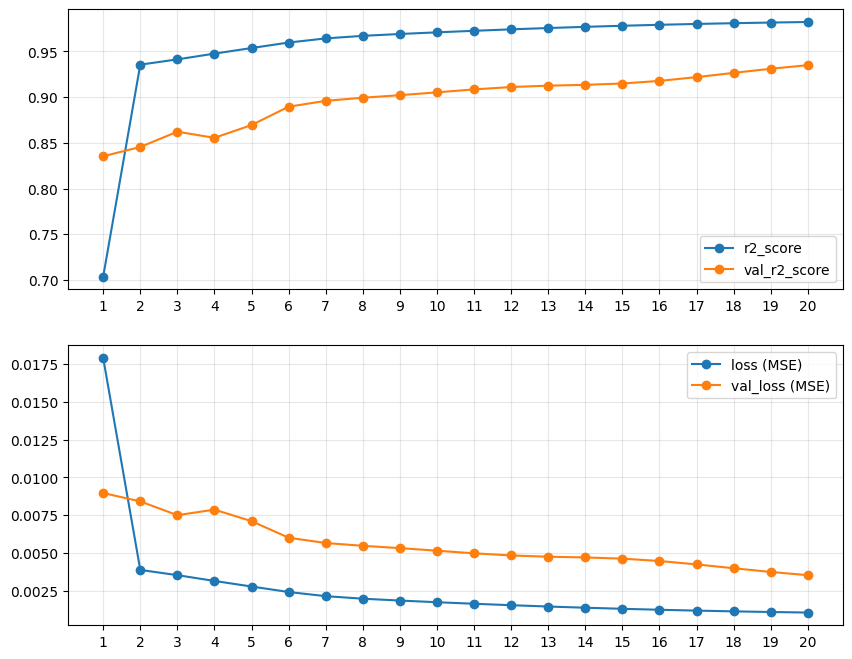

In [ ]:
x_axis = np.array(train_result.epoch) + 1

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(x_axis, train_result.history["r2_score"], marker="o", label="r2_score")
plt.plot(x_axis, train_result.history["val_r2_score"], marker="o", label="val_r2_score")
plt.xticks(x_axis)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x_axis, train_result.history["loss"], marker="o", label="loss (MSE)")
plt.plot(x_axis, train_result.history["val_loss"], marker="o", label="val_loss (MSE)")
plt.xticks(x_axis)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Prediction

In [ ]:
y_pred = rnn_model.predict(X_test, batch_size=1)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
scaler_y = joblib.load(f"{t.MODEL_PATH}/scaler_y.save")

In [ ]:
y_pred_unscaled = scaler_y.inverse_transform(y_pred)
y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
r2 = r2_score(y_test_unscaled, y_pred_unscaled)
mse = mean_squared_error(y_test_unscaled, y_pred_unscaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, y_pred_unscaled)

print(f"R2:   {r2:.3f}\nMSE:  {mse:.3f}\nRMSE: {rmse:.3f}\nMAE:  {mae:.3f}")

R2:   0.942
MSE:  12938.958
RMSE: 113.750
MAE:  90.413


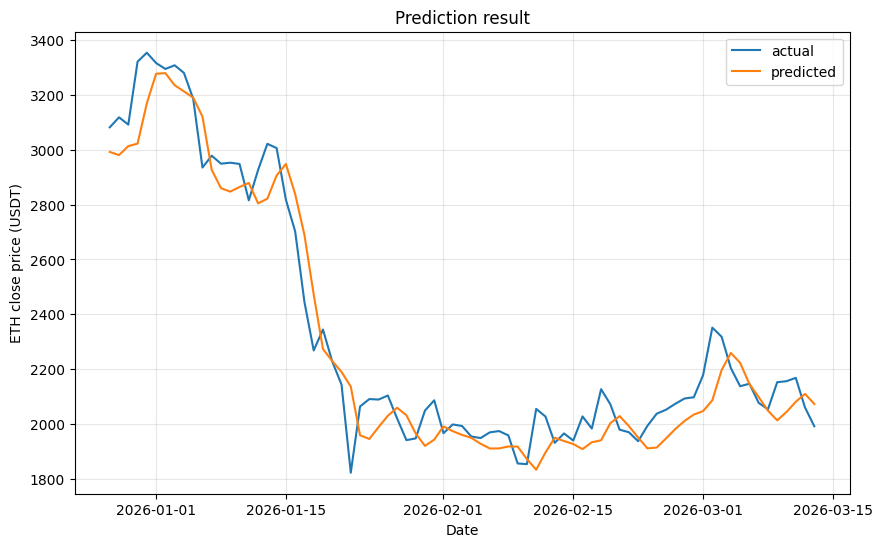

In [ ]:
date = df.index[-t.TIME_STEP - len(X_test):-t.TIME_STEP]

plt.figure(figsize=(10, 6))
plt.plot(date, y_test_unscaled, label="actual")
plt.plot(date, y_pred_unscaled, label="predicted")
plt.xlabel("Date")
plt.ylabel("ETH close price (USDT)")
plt.title("Prediction result")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(f"{t.IMAGE_PATH}/base_prediction_result.png", format="png")
plt.show()